In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data=pd.read_csv("../../data/RNA_Celligner/Data_used_for_Figs4AB_HCMImodelsvsCCLE.csv", index_col=0)
data.head()

,Case_id3,Model_id3,Aliquot_id3,Exclusion_list,Case_ID,Model_ID,CMDC,GDC_Released,Multiple_Models,Sex,...,Diagnosis_TMP_HCMI_Code,CCLE_Disease_Subtype,CCLE_Disease,Color_Code,Culture_Media,Growth_Pattern,Culture_System,Treatment_Status,index,cell_type
0,HCM-BROD-0001-C18,HCM-BROD-0001-C18,HCM-BROD-0001-C18-85M,NaN,HCM-BROD-0001-C18,HCM-BROD-0001-C18,BROD,True,False,Female,...,COADREAD,Adenocarcinoma,Colon/Colorectal Cancer,#DAF1FC,CM,3D Spheroid,Spheroid,Treated,NaN,HCMI Model
1,HCM-BROD-0002-C71,HCM-BROD-0002-C71,HCM-BROD-0002-C71-85A,NaN,HCM-BROD-0002-C71,HCM-BROD-0002-C71,BROD,True,False,Male,...,LGGGBM,Glioblastoma,Brain Cancer,#B2509E,CM,2D Cell Line,Adherent,Treatment Naïve,NaN,HCMI Model
2,HCM-BROD-0003-C71,HCM-BROD-0003-C71,HCM-BROD-0003-C71-85B,NaN,HCM-BROD-0003-C71,HCM-BROD-0003-C71,BROD,True,False,Female,...,LGGGBM,Glioblastoma,Brain Cancer,#B2509E,CM,2D Cell Line,Adherent,Treatment Naïve,NaN,HCMI Model
3,HCM-BROD-0004-C64,HCM-BROD-0004-C64,HCM-BROD-0004-C64-85R,NaN,HCM-BROD-0004-C64,HCM-BROD-0004-C64,BROD,False,False,Female,...,WT,NA_CCLE,Kidney Cancer,#754C29,FM,2D Cell Line,Adherent,Treatment Naïve,NaN,HCMI Model
4,HCM-BROD-0007-C49,HCM-BROD-0007-C49,HCM-BROD-0007-C49-85B,NaN,HCM-BROD-0007-C49,HCM-BROD-0007-C49,BROD,True,False,Male,...,SARC,Rhabdomyosarcoma,Sarcoma,#00A99D,CM,3D Spheroid,Mixed,Treatment Naïve,NaN,HCMI Model


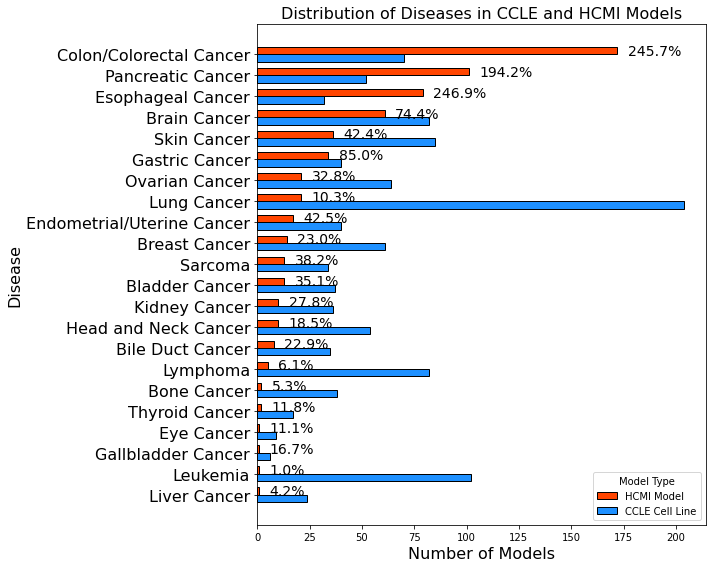

In [3]:
plt.rcParams['pdf.fonttype'] = 42

cancer_type_counts = data.\
groupby(['CCLE_Disease', 'cell_type']).size().reset_index(name='counts')

cancer_type_counts_pivot = cancer_type_counts.pivot(index='CCLE_Disease', columns='cell_type', values='counts').fillna(0)

cancer_type_counts_pivot = cancer_type_counts_pivot[cancer_type_counts_pivot['HCMI Model'] > 0]
cancer_type_counts_pivot = cancer_type_counts_pivot[cancer_type_counts_pivot['CCLE Cell Line'] > 0]

# Calculate percentage increase 
cancer_type_counts_pivot['percentage_increase'] = (cancer_type_counts_pivot['HCMI Model'] / cancer_type_counts_pivot['CCLE Cell Line']) * 100

# Sort by HCMI Model in descending order 
cancer_type_counts_pivot.sort_values(by='HCMI Model', ascending=True, inplace=True)

# Main plot
fig, ax = plt.subplots(figsize=(10, 8))
bar_height = 0.35
bar_spacing = np.arange(len(cancer_type_counts_pivot))

# Plot HCMI Models (red bar) 
ax.barh(
    bar_spacing + bar_height / 2,  # Shift HCMI bars to the left
    cancer_type_counts_pivot['HCMI Model'],
    color='orangered',
    edgecolor='k',
    height=bar_height,
    label='HCMI Model'
)

# Plot CCLE Cell Lines (blue bar)
ax.barh(
    bar_spacing - bar_height / 2,  # Shift CCLE bars to the right
    cancer_type_counts_pivot['CCLE Cell Line'],
    color='dodgerblue',
    edgecolor='k',
    height=bar_height,
    label='CCLE Cell Line'
)

# Add percentage increase annotations 
for i, (idx, row) in enumerate(cancer_type_counts_pivot.iterrows()):
    percentage_increase = row['percentage_increase']
    hcmi_count = row['HCMI Model']
    ax.text(hcmi_count + 5, bar_spacing[i] + bar_height / 2, f'{percentage_increase:.1f}%', va='center', ha='left', fontsize=14, color='black')


ax.set_yticks(bar_spacing)
ax.set_yticklabels(cancer_type_counts_pivot.index, size=16) 
ax.set_ylabel('Disease', size=16)
ax.set_xlabel('Number of Models', size=16)
ax.set_title('Distribution of Diseases in CCLE and HCMI Models', size=16)
ax.legend(title='Model Type')

plt.tight_layout()
plt.show()


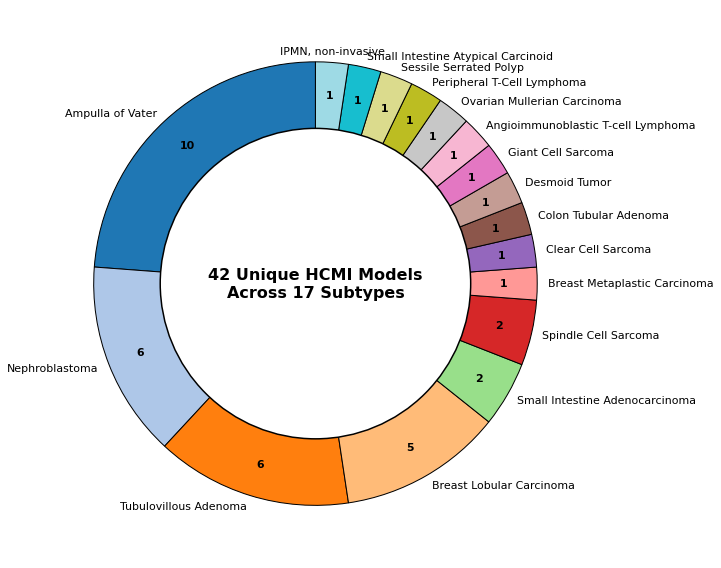

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# setup
cancer_type_counts=data[data['CCLE_Disease_Subtype']=='NA_CCLE']


cancer_type_counts = cancer_type_counts.groupby(['Primary_Diagnosis', 'cell_type']).size().reset_index(name='counts')
cancer_type_counts_pivot = cancer_type_counts.pivot(index='Primary_Diagnosis', columns='cell_type', values='counts').fillna(0)


cancer_type_counts_pivot=cancer_type_counts_pivot[cancer_type_counts_pivot['HCMI Model']>0]


cancer_type_counts_pivot = cancer_type_counts_pivot[
    (cancer_type_counts_pivot['HCMI Model'] > 0)
]


# Sort by HCMI Model in descending order
cancer_type_counts_pivot.sort_values(by='HCMI Model', ascending=False, inplace=True)

data2 = cancer_type_counts_pivot.copy()
colors = plt.get_cmap('tab20')(np.linspace(0, 1, len(data2)))

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(aspect="equal"))

# Plot donut chart
wedges, _ = ax.pie(
    data2['HCMI Model'],
    labels=None,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='k')
)

center_circle = plt.Circle((0, 0), 0.7, facecolor='white', edgecolor='black', linewidth=1.5)
ax.add_artist(center_circle)

plt.text(0, 0, f"{int(data2['HCMI Model'].sum())} Unique HCMI Models\nAcross {len(data2)} Subtypes",
         ha='center', va='center', fontsize=16, fontweight='bold')

# Add sample counts 
for i, p in enumerate(wedges):
    angle = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(angle)) * 0.85
    y = np.sin(np.deg2rad(angle)) * 0.85

    ax.text(x, y, str(int(data2['HCMI Model'].iloc[i])),
            ha='center', va='center', fontsize=11, fontweight='bold')

# Add subtype labels 
for i, p in enumerate(wedges):
    angle = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(angle)) * 1.05
    y = np.sin(np.deg2rad(angle)) * 1.05

    subtype = data2.index[i]
    ax.text(x, y, subtype,
            ha='center' if abs(x) < 0.1 else ('left' if x > 0 else 'right'),
            va='center', fontsize=11)

plt.tight_layout()
plt.show()
